# Feature Store de Telemetria

Notebook para construir uma Feature Store a partir dos dados de telemetria de rede gerados pelo protótipo:
- `prototipo/relatorios/banda_tratada_rota_*.csv` (colunas `datetime`, `interface`, `taxa_total_Mbps`, `banda_disponivel`)
- `prototipo/relatorios/latencia_rota_*.txt` (colunas `datetime`, `latencia_ms`)

Etapas:
1. Descoberta e ingestão dos arquivos brutos de banda
2. Normalização e concatenação
3. Agregação temporal da banda (alinhamento por segundo)
4. Feature engineering (pivotagem por interface)
5. Ingestão e agregação temporal dos dados de latência
6. Consolidação: junção de banda e latência (por tempo relativo)
7. Engenharia de features de janela deslizante multi-resolução (p95, jitter, tendência, mínimos, deltas e cross-features como BDP e latência por salto)
8. Persistência em formato Parquet particionado
9. Visualização de validação (banda, latência e features derivadas)
10. Exemplo de consulta à Feature Store

## 1. Import de bibliotecas

In [1]:
import os
import re
import glob
from pathlib import Path

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

import warnings
warnings.filterwarnings("ignore")

pd.set_option('max_colwidth', 800)


## 2. Descoberta dos arquivos de origem

Localiza todos os arquivos `banda_tratada_rota_*.csv` na pasta `prototipo/relatorios`.

In [2]:
RELATORIOS_FOLDER = 'prototipo/relatorios'
FEATURE_STORE_FOLDER = 'feature_store/data'

os.makedirs(FEATURE_STORE_FOLDER, exist_ok=True)

padrao_arquivo = os.path.join(RELATORIOS_FOLDER, 'banda_tratada_rota_*.csv')
arquivos_banda = sorted(glob.glob(padrao_arquivo))

print(f"Encontrados {len(arquivos_banda)} arquivos:")
for arquivo in arquivos_banda:
    print(f" - {arquivo}")


Encontrados 4 arquivos:
 - prototipo/relatorios/banda_tratada_rota_h11_h61.csv
 - prototipo/relatorios/banda_tratada_rota_h12_h62.csv
 - prototipo/relatorios/banda_tratada_rota_h13_h63.csv
 - prototipo/relatorios/banda_tratada_rota_h14_h64.csv


## 3. Ingestão e normalização

Para cada arquivo, extrai o identificador da rota do nome (ex: `banda_tratada_rota_h11_h61.csv` → `h11_h61`), converte a coluna `datetime` e adiciona metadados (`rota_id`, `origem_arquivo`).

In [3]:
padrao_rota = re.compile(r'banda_tratada_rota_(.+)\.csv$')

def extrair_rota_id(caminho_arquivo):
    nome = os.path.basename(caminho_arquivo)
    match = padrao_rota.search(nome)
    return match.group(1) if match else nome

def ingerir_arquivo(caminho_arquivo):
    df = pd.read_csv(caminho_arquivo)
    df['datetime'] = pd.to_datetime(df['datetime'])
    df['rota_id'] = extrair_rota_id(caminho_arquivo)
    df['origem_arquivo'] = os.path.basename(caminho_arquivo)
    return df

def ingerir_todos(arquivos):
    dfs = []
    for arquivo in arquivos:
        try:
            dfs.append(ingerir_arquivo(arquivo))
        except Exception as e:
            print(f"Erro ao ler {arquivo}: {e}")
    if not dfs:
        return pd.DataFrame(columns=['datetime', 'interface', 'taxa_total_Mbps', 'banda_disponivel', 'rota_id', 'origem_arquivo'])
    return pd.concat(dfs, ignore_index=True)

df_bruto = ingerir_todos(arquivos_banda)

print(f"Shape do dataframe bruto: {df_bruto.shape}")
print(f"Rotas encontradas: {df_bruto['rota_id'].unique().tolist()}")
df_bruto.head()


Shape do dataframe bruto: (864, 6)
Rotas encontradas: ['h11_h61', 'h12_h62', 'h13_h63', 'h14_h64']


,datetime,interface,taxa_total_Mbps,banda_disponivel,rota_id,origem_arquivo
0,2026-08-18 02:12:31.102340864,s2-eth2,0.000000,100.000000,h11_h61,banda_tratada_rota_h11_h61.csv
1,2026-08-18 02:12:31.102382848,s3-eth2,0.000000,100.000000,h11_h61,banda_tratada_rota_h11_h61.csv
2,2026-08-18 02:12:32.102885120,s1-eth1,0.000641,99.999359,h11_h61,banda_tratada_rota_h11_h61.csv
3,2026-08-18 02:12:32.102979840,s2-eth2,0.000641,99.999359,h11_h61,banda_tratada_rota_h11_h61.csv
4,2026-08-18 02:12:32.103017216,s3-eth2,0.000641,99.999359,h11_h61,banda_tratada_rota_h11_h61.csv


## 4. Agregação temporal

Os timestamps possuem precisão de microssegundos e chegam em instantes ligeiramente diferentes por interface. Arredondamos para o segundo mais próximo e agregamos por média, agrupando por `rota_id`, `interface` e `timestamp`.

In [4]:
def agregar_por_segundo(df, freq='1s'):
    df_agg = df.copy()
    df_agg['timestamp'] = df_agg['datetime'].dt.round(freq)

    df_agg = (
        df_agg
        .groupby(['rota_id', 'interface', 'timestamp'], as_index=False)
        .agg(
            taxa_total_Mbps=('taxa_total_Mbps', 'mean'),
            banda_disponivel=('banda_disponivel', 'mean')
        )
    )
    return df_agg

df_agregado = agregar_por_segundo(df_bruto)

print(f"Shape do dataframe agregado: {df_agregado.shape}")
df_agregado.head()


Shape do dataframe agregado: (864, 5)


,rota_id,interface,timestamp,taxa_total_Mbps,banda_disponivel
0,h11_h61,s1-eth1,2026-08-18 02:12:32,0.000641,99.999359
1,h11_h61,s1-eth1,2026-08-18 02:12:33,15.808823,84.191177
2,h11_h61,s1-eth1,2026-08-18 02:12:34,19.703384,80.296616
3,h11_h61,s1-eth1,2026-08-18 02:12:35,18.861938,81.138062
4,h11_h61,s1-eth1,2026-08-18 02:12:36,19.627010,80.372990


In [5]:
# Verificação: a agregação de fato "colapsou" alguma leitura?
df_bruto_check = df_bruto.copy()
df_bruto_check['timestamp'] = df_bruto_check['datetime'].dt.round('1s')

contagem_por_segundo = (
    df_bruto_check
    .groupby(['rota_id', 'interface', 'timestamp'])
    .size()
    .reset_index(name='qtd_leituras')
)

duplicados = contagem_por_segundo[contagem_por_segundo['qtd_leituras'] > 1]

print(f"Linhas no bruto: {len(df_bruto)}")
print(f"Linhas no agregado: {len(df_agregado)}")
print(f"Grupos (rota_id, interface, timestamp) com mais de 1 leitura no mesmo segundo: {len(duplicados)}")

if len(duplicados) > 0:
    print("\nExemplos de grupos com múltiplas leituras no mesmo segundo:")
    display(duplicados.sort_values('qtd_leituras', ascending=False).head())
else:
    print("\nNenhuma duplicata por segundo encontrada — a agregação apenas truncou os microssegundos,")
    print("sem de fato reduzir o número de linhas. Ainda assim, ela é essencial para permitir o merge")
    print("com os dados de latência (que têm timestamps de origem diferentes).")


Linhas no bruto: 864
Linhas no agregado: 864
Grupos (rota_id, interface, timestamp) com mais de 1 leitura no mesmo segundo: 0

Nenhuma duplicata por segundo encontrada — a agregação apenas truncou os microssegundos,
sem de fato reduzir o número de linhas. Ainda assim, ela é essencial para permitir o merge
com os dados de latência (que têm timestamps de origem diferentes).


## 5. Feature engineering (pivotagem por interface)

Transforma cada interface em colunas de features, gerando `taxa_total_Mbps__{interface}` e `banda_disponivel__{interface}`, indexadas por `rota_id` e `timestamp`.

In [10]:
def pivotar_features(df_agregado):
    pivot_taxa = df_agregado.pivot_table(
        index=['rota_id', 'timestamp'],
        columns='interface',
        values='taxa_total_Mbps'
    )
    pivot_taxa.columns = [f'taxa_total_Mbps__{col}' for col in pivot_taxa.columns]

    pivot_banda = df_agregado.pivot_table(
        index=['rota_id', 'timestamp'],
        columns='interface',
        values='banda_disponivel'
    )
    pivot_banda.columns = [f'banda_disponivel__{col}' for col in pivot_banda.columns]

    df_features = pivot_taxa.join(pivot_banda, how='outer').reset_index()
    df_features = df_features.sort_values(['rota_id', 'timestamp']).reset_index(drop=True)
    return df_features

df_feature_store = pivotar_features(df_agregado)

print(f"Shape da feature store: {df_feature_store.shape}")
print(f"Colunas: {df_feature_store.columns.tolist()}")
df_feature_store.head()


Shape da feature store: (248, 18)
Colunas: ['rota_id', 'timestamp', 'taxa_total_Mbps__s1-eth1', 'taxa_total_Mbps__s1-eth2', 'taxa_total_Mbps__s2-eth2', 'taxa_total_Mbps__s2-eth3', 'taxa_total_Mbps__s3-eth2', 'taxa_total_Mbps__s4-eth2', 'taxa_total_Mbps__s5-eth1', 'taxa_total_Mbps__s5-eth3', 'banda_disponivel__s1-eth1', 'banda_disponivel__s1-eth2', 'banda_disponivel__s2-eth2', 'banda_disponivel__s2-eth3', 'banda_disponivel__s3-eth2', 'banda_disponivel__s4-eth2', 'banda_disponivel__s5-eth1', 'banda_disponivel__s5-eth3']


,rota_id,timestamp,taxa_total_Mbps__s1-eth1,taxa_total_Mbps__s1-eth2,taxa_total_Mbps__s2-eth2,taxa_total_Mbps__s2-eth3,taxa_total_Mbps__s3-eth2,taxa_total_Mbps__s4-eth2,taxa_total_Mbps__s5-eth1,taxa_total_Mbps__s5-eth3,banda_disponivel__s1-eth1,banda_disponivel__s1-eth2,banda_disponivel__s2-eth2,banda_disponivel__s2-eth3,banda_disponivel__s3-eth2,banda_disponivel__s4-eth2,banda_disponivel__s5-eth1,banda_disponivel__s5-eth3
0,h11_h61,2026-08-18 02:12:31,NaN,NaN,0.000000,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,100.000000,NaN,100.000000,NaN,NaN,NaN
1,h11_h61,2026-08-18 02:12:32,0.000641,NaN,0.000641,NaN,0.000641,NaN,NaN,NaN,99.999359,NaN,99.999359,NaN,99.999359,NaN,NaN,NaN
2,h11_h61,2026-08-18 02:12:33,15.808823,NaN,15.672409,NaN,15.478409,NaN,NaN,NaN,84.191177,NaN,84.327591,NaN,84.521591,NaN,NaN,NaN
3,h11_h61,2026-08-18 02:12:34,19.703384,NaN,19.805695,NaN,19.930740,NaN,NaN,NaN,80.296616,NaN,80.194305,NaN,80.069260,NaN,NaN,NaN
4,h11_h61,2026-08-18 02:12:35,18.861938,NaN,18.850739,NaN,18.862675,NaN,NaN,NaN,81.138062,NaN,81.149261,NaN,81.137325,NaN,NaN,NaN


## 6. Ingestão dos dados de latência

Os arquivos `latencia_rota_*.txt` contêm duas colunas separadas por tabulação: `datetime` e `latencia_ms` (podendo conter o valor `None`). Extraímos o `rota_id` do nome do arquivo, convertemos os tipos e alinhamos ao mesmo grid temporal (segundo) usado para os dados de banda.

In [7]:
padrao_latencia_arquivo = os.path.join(RELATORIOS_FOLDER, 'latencia_rota_*.txt')
arquivos_latencia = sorted(glob.glob(padrao_latencia_arquivo))

padrao_rota_latencia = re.compile(r'latencia_rota_(.+)\.txt$')

def extrair_rota_id_latencia(caminho_arquivo):
    nome = os.path.basename(caminho_arquivo)
    match = padrao_rota_latencia.search(nome)
    return match.group(1) if match else nome

def ingerir_arquivo_latencia(caminho_arquivo):
    df = pd.read_csv(
        caminho_arquivo,
        sep='\t',
        header=None,
        names=['datetime', 'latencia_ms']
    )
    df['datetime'] = pd.to_datetime(df['datetime'])
    df['latencia_ms'] = pd.to_numeric(df['latencia_ms'], errors='coerce')
    df['rota_id'] = extrair_rota_id_latencia(caminho_arquivo)
    df['origem_arquivo'] = os.path.basename(caminho_arquivo)
    return df

def ingerir_todas_latencias(arquivos):
    dfs = []
    for arquivo in arquivos:
        try:
            dfs.append(ingerir_arquivo_latencia(arquivo))
        except Exception as e:
            print(f"Erro ao ler {arquivo}: {e}")
    if not dfs:
        return pd.DataFrame(columns=['datetime', 'latencia_ms', 'rota_id', 'origem_arquivo'])
    return pd.concat(dfs, ignore_index=True)

df_latencia_bruto = ingerir_todas_latencias(arquivos_latencia)

print(f"Shape do dataframe de latência bruto: {df_latencia_bruto.shape}")
print(f"Rotas encontradas: {df_latencia_bruto['rota_id'].unique().tolist()}")
df_latencia_bruto.head()


Shape do dataframe de latência bruto: (121, 4)
Rotas encontradas: ['h11_h61', 'h12_h62', 'h13_h63', 'h14_h64']


,datetime,latencia_ms,rota_id,origem_arquivo
0,2026-08-17 19:13:29,NaN,h11_h61,latencia_rota_h11_h61.txt
1,2026-08-17 19:13:30,NaN,h11_h61,latencia_rota_h11_h61.txt
2,2026-08-17 19:13:31,50.978306,h11_h61,latencia_rota_h11_h61.txt
3,2026-08-17 19:13:32,29.785503,h11_h61,latencia_rota_h11_h61.txt
4,2026-08-17 19:13:33,51.230175,h11_h61,latencia_rota_h11_h61.txt


In [8]:
def agregar_latencia_por_segundo(df, freq='1s'):
    df_agg = df.copy()
    df_agg['timestamp'] = df_agg['datetime'].dt.round(freq)

    df_agg = (
        df_agg
        .groupby(['rota_id', 'timestamp'], as_index=False)
        .agg(latencia_ms=('latencia_ms', 'mean'))
    )
    return df_agg

df_latencia_agregado = agregar_latencia_por_segundo(df_latencia_bruto)

print(f"Shape da latência agregada: {df_latencia_agregado.shape}")
df_latencia_agregado.head()


Shape da latência agregada: (121, 3)


,rota_id,timestamp,latencia_ms
0,h11_h61,2026-08-17 19:13:29,NaN
1,h11_h61,2026-08-17 19:13:30,NaN
2,h11_h61,2026-08-17 19:13:31,50.978306
3,h11_h61,2026-08-17 19:13:32,29.785503
4,h11_h61,2026-08-17 19:13:33,51.230175


## 7. Consolidação: junção de banda e latência

Junta a tabela de features de banda (pivotada por interface) com a feature de `latencia_ms`, por `rota_id` e `timestamp`, formando a tabela final da Feature Store.

**Atenção:** os arquivos de banda e latência podem ter sido gerados em execuções diferentes do protótipo (datas/horários absolutos distintos). Por isso, em vez de unir pelo `timestamp` absoluto, alinhamos por **tempo relativo** (segundos decorridos desde o início da coleta de cada `rota_id`), que reflete melhor a posição de cada leitura dentro do experimento.

In [11]:
def adicionar_tempo_relativo(df, coluna_timestamp='timestamp'):
    df = df.copy()
    inicio_por_rota = df.groupby('rota_id')[coluna_timestamp].transform('min')
    df['tempo_relativo_s'] = (df[coluna_timestamp] - inicio_por_rota).dt.total_seconds().astype(int)
    return df

df_feature_store_rel = adicionar_tempo_relativo(df_feature_store)
df_latencia_agregado_rel = adicionar_tempo_relativo(df_latencia_agregado)

df_feature_store = df_feature_store_rel.merge(
    df_latencia_agregado_rel.drop(columns=['timestamp']),
    on=['rota_id', 'tempo_relativo_s'],
    how='outer',
    suffixes=('', '_latencia')
)

df_feature_store = df_feature_store.sort_values(['rota_id', 'tempo_relativo_s']).reset_index(drop=True)

print(f"Shape da feature store consolidada: {df_feature_store.shape}")
print(f"Colunas: {df_feature_store.columns.tolist()}")

qtd_com_ambos = df_feature_store.dropna(subset=['taxa_total_Mbps__s1-eth1', 'latencia_ms'], how='any').shape[0] \
    if 'taxa_total_Mbps__s1-eth1' in df_feature_store.columns else None
qtd_com_latencia = df_feature_store['latencia_ms'].notna().sum()
print(f"Linhas com latência preenchida: {qtd_com_latencia} de {len(df_feature_store)}")

df_feature_store.head()


Shape da feature store consolidada: (248, 20)
Colunas: ['rota_id', 'timestamp', 'taxa_total_Mbps__s1-eth1', 'taxa_total_Mbps__s1-eth2', 'taxa_total_Mbps__s2-eth2', 'taxa_total_Mbps__s2-eth3', 'taxa_total_Mbps__s3-eth2', 'taxa_total_Mbps__s4-eth2', 'taxa_total_Mbps__s5-eth1', 'taxa_total_Mbps__s5-eth3', 'banda_disponivel__s1-eth1', 'banda_disponivel__s1-eth2', 'banda_disponivel__s2-eth2', 'banda_disponivel__s2-eth3', 'banda_disponivel__s3-eth2', 'banda_disponivel__s4-eth2', 'banda_disponivel__s5-eth1', 'banda_disponivel__s5-eth3', 'tempo_relativo_s', 'latencia_ms']
Linhas com latência preenchida: 116 de 248


,rota_id,timestamp,taxa_total_Mbps__s1-eth1,taxa_total_Mbps__s1-eth2,taxa_total_Mbps__s2-eth2,taxa_total_Mbps__s2-eth3,taxa_total_Mbps__s3-eth2,taxa_total_Mbps__s4-eth2,taxa_total_Mbps__s5-eth1,taxa_total_Mbps__s5-eth3,banda_disponivel__s1-eth1,banda_disponivel__s1-eth2,banda_disponivel__s2-eth2,banda_disponivel__s2-eth3,banda_disponivel__s3-eth2,banda_disponivel__s4-eth2,banda_disponivel__s5-eth1,banda_disponivel__s5-eth3,tempo_relativo_s,latencia_ms
0,h11_h61,2026-08-18 02:12:31,NaN,NaN,0.000000,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,100.000000,NaN,100.000000,NaN,NaN,NaN,0,NaN
1,h11_h61,2026-08-18 02:12:32,0.000641,NaN,0.000641,NaN,0.000641,NaN,NaN,NaN,99.999359,NaN,99.999359,NaN,99.999359,NaN,NaN,NaN,1,NaN
2,h11_h61,2026-08-18 02:12:33,15.808823,NaN,15.672409,NaN,15.478409,NaN,NaN,NaN,84.191177,NaN,84.327591,NaN,84.521591,NaN,NaN,NaN,2,50.978306
3,h11_h61,2026-08-18 02:12:34,19.703384,NaN,19.805695,NaN,19.930740,NaN,NaN,NaN,80.296616,NaN,80.194305,NaN,80.069260,NaN,NaN,NaN,3,29.785503
4,h11_h61,2026-08-18 02:12:35,18.861938,NaN,18.850739,NaN,18.862675,NaN,NaN,NaN,81.138062,NaN,81.149261,NaN,81.137325,NaN,NaN,NaN,4,51.230175


## 7.1 Engenharia de features de janela deslizante (multi-resolução)

Cada leitura já está alinhada por segundo (`tempo_relativo_s`), mas o valor "instantâneo" de latência/banda não captura tendência nem estabilidade. Aqui derivamos, para múltiplas janelas de tempo, as features discutidas:

**Latência (desempenho e estabilidade):**
- `latencia_p95_{w}s`: percentil 95 dentro da janela (pior cenário habitual)
- `latencia_jitter_{w}s`: desvio padrão (instabilidade)
- `latencia_delta_curta_longa`: tendência (janela curta - janela longa)

**Banda (capacidade e gargalos):**
- `banda_disp_min_{w}s`: mínimo na janela (gargalo)
- `banda_disp_media_{w}s`: média na janela
- `banda_utilizacao_{w}s`: proporção da banda disponível em relação a 100%

**Cross-features:**
- `bdp_{w}s`: Bandwidth-Delay Product (banda_disponivel_media × latência_média), indicador de dados "em trânsito"
- `latencia_por_salto`: latência total / número de interfaces ativas na rota (proxy de saltos)

Como nossas coletas têm apenas ~60-90 segundos de duração (não horas), usamos janelas curtas como **proxy multi-resolução**: 5s (micro), 15s (curto prazo) e 30s (longo prazo relativo ao experimento). O conceito é o mesmo descrito: comparar diferentes horizontes de tempo.

*Nota: Route Flapping não foi incluído, pois a topologia não varia durante uma coleta (confirmado pela orientação).*

In [16]:
JANELAS_SEGUNDOS = {
    'micro': 5,    # 5s  - picos rápidos / microbursts
    'curta': 15,   # 15s - tendência de curto prazo
    'longa': 30,   # 30s - baseline / contexto do experimento
}

def colunas_banda_disponivel(df):
    return [c for c in df.columns if c.startswith('banda_disponivel__')]

def colunas_taxa(df):
    return [c for c in df.columns if c.startswith('taxa_total_Mbps__')]

def calcular_features_janela(df_feature_store, janelas=JANELAS_SEGUNDOS):
    """
    Para cada rota_id, ordena por tempo_relativo_s e calcula, para cada janela (em segundos):
      - latencia_p95, latencia_jitter (std)
      - banda_disponivel_media (agregada entre interfaces) min e média
      - banda_utilizacao (media / 100)
    Tudo com sliding window (rolling) sobre o índice temporal de 1s, com overlap total (stride=1).
    """
    df = df_feature_store.sort_values(['rota_id', 'tempo_relativo_s']).reset_index(drop=True).copy()

    # Banda disponível média entre todas as interfaces da rota, por linha (proxy da banda do caminho)
    cols_banda = colunas_banda_disponivel(df)
    df['banda_disponivel_media_interfaces'] = df[cols_banda].mean(axis=1) if cols_banda else np.nan

    resultado = []
    for rota_id, grupo in df.groupby('rota_id'):
        grupo = grupo.sort_values('tempo_relativo_s').set_index('tempo_relativo_s')

        for nome_janela, w in janelas.items():
            janela_latencia = grupo['latencia_ms'].rolling(window=w, min_periods=1)
            janela_banda = grupo['banda_disponivel_media_interfaces'].rolling(window=w, min_periods=1)

            grupo[f'latencia_p95_{nome_janela}_{w}s'] = janela_latencia.quantile(0.95)
            grupo[f'latencia_jitter_{nome_janela}_{w}s'] = janela_latencia.std()
            grupo[f'latencia_media_{nome_janela}_{w}s'] = janela_latencia.mean()

            grupo[f'banda_disp_min_{nome_janela}_{w}s'] = janela_banda.min()
            grupo[f'banda_disp_media_{nome_janela}_{w}s'] = janela_banda.mean()
            grupo[f'banda_utilizacao_{nome_janela}_{w}s'] = 1 - (janela_banda.mean() / 100)

        resultado.append(grupo.reset_index())

    return pd.concat(resultado, ignore_index=True)

df_feature_store = calcular_features_janela(df_feature_store)

print(f"Shape após features de janela: {df_feature_store.shape}")
novas_colunas = [c for c in df_feature_store.columns if any(c.startswith(p) for p in ['latencia_p95', 'latencia_jitter', 'latencia_media', 'banda_disp_min', 'banda_disp_media', 'banda_utilizacao'])]
print(f"Novas colunas de janela ({len(novas_colunas)}): {novas_colunas}")
df_feature_store[['rota_id', 'tempo_relativo_s', 'latencia_ms'] + novas_colunas].head(10)


Shape após features de janela: (248, 39)
Novas colunas de janela (18): ['latencia_p95_micro_5s', 'latencia_jitter_micro_5s', 'latencia_media_micro_5s', 'banda_disp_min_micro_5s', 'banda_disp_media_micro_5s', 'banda_utilizacao_micro_5s', 'latencia_p95_curta_15s', 'latencia_jitter_curta_15s', 'latencia_media_curta_15s', 'banda_disp_min_curta_15s', 'banda_disp_media_curta_15s', 'banda_utilizacao_curta_15s', 'latencia_p95_longa_30s', 'latencia_jitter_longa_30s', 'latencia_media_longa_30s', 'banda_disp_min_longa_30s', 'banda_disp_media_longa_30s', 'banda_utilizacao_longa_30s']


,rota_id,tempo_relativo_s,latencia_ms,latencia_p95_micro_5s,latencia_jitter_micro_5s,latencia_media_micro_5s,banda_disp_min_micro_5s,banda_disp_media_micro_5s,banda_utilizacao_micro_5s,latencia_p95_curta_15s,...,latencia_media_curta_15s,banda_disp_min_curta_15s,banda_disp_media_curta_15s,banda_utilizacao_curta_15s,latencia_p95_longa_30s,latencia_jitter_longa_30s,latencia_media_longa_30s,banda_disp_min_longa_30s,banda_disp_media_longa_30s,banda_utilizacao_longa_30s
0,h11_h61,0,NaN,NaN,NaN,NaN,100.000000,100.000000,0.000000,NaN,...,NaN,100.000000,100.000000,0.000000,NaN,NaN,NaN,100.000000,100.000000,0.000000
1,h11_h61,1,NaN,NaN,NaN,NaN,99.999359,99.999680,0.000003,NaN,...,NaN,99.999359,99.999680,0.000003,NaN,NaN,NaN,99.999359,99.999680,0.000003
2,h11_h61,2,50.978306,50.978306,NaN,50.978306,84.346786,94.782049,0.052180,50.978306,...,50.978306,84.346786,94.782049,0.052180,50.978306,NaN,50.978306,84.346786,94.782049,0.052180
3,h11_h61,3,29.785503,49.918666,14.985575,40.381905,80.186727,91.133218,0.088668,49.918666,...,40.381905,80.186727,91.133218,0.088668,49.918666,14.985575,40.381905,80.186727,91.133218,0.088668
4,h11_h61,4,51.230175,51.204988,12.309023,43.997995,80.186727,89.134884,0.108651,51.204988,...,43.997995,80.186727,89.134884,0.108651,51.204988,12.309023,43.997995,80.186727,89.134884,0.108651
5,h11_h61,5,66.472070,64.185786,15.075777,49.616514,80.186727,85.212478,0.147875,64.185786,...,49.616514,80.186727,87.677065,0.123229,64.185786,15.075777,49.616514,80.186727,87.677065,0.123229
6,h11_h61,6,33.287741,63.423691,14.959447,46.350759,80.046026,81.221811,0.187782,63.423691,...,46.350759,80.046026,86.586916,0.134131,63.423691,14.959447,46.350759,80.046026,86.586916,0.134131
7,h11_h61,7,47.454748,63.423691,14.768731,45.646047,80.046026,80.394149,0.196059,62.661596,...,46.534757,80.046026,85.789611,0.142104,62.661596,13.387725,46.534757,80.046026,85.789611,0.142104
8,h11_h61,8,41.105758,63.423691,12.408560,47.910098,80.046026,80.390310,0.196097,61.899501,...,45.759186,80.046026,85.164936,0.148351,61.899501,12.392332,45.759186,80.046026,85.164936,0.148351
9,h11_h61,9,29.014412,62.668605,14.690179,43.466946,80.046026,80.262847,0.197372,61.137407,...,43.666089,80.046026,84.698865,0.153011,61.137407,12.910452,43.666089,80.046026,84.698865,0.153011


## 7.2 Deltas entre janelas e Cross-Features

- **Delta de Latência** (`latencia_delta_micro_longa`): compara a janela micro (5s) com a longa (30s). Se positivo e crescendo, indica congestionamento se formando *agora*.
- **Delta de Banda** (`banda_delta_micro_longa`): razão entre banda mínima na janela micro e a média na janela longa — mede a severidade do gargalo atual frente ao "normal" da coleta.
- **BDP (Bandwidth-Delay Product)**: `banda_disponivel_media_interfaces × latência_ms` — quantidade de dados "em trânsito" na rede.
- **Latência por salto**: `latência_ms / número de interfaces ativas na rota` — indica se o atraso vem de processamento nos roteadores (fila) ou de distância física.

In [17]:
def contar_interfaces_ativas_por_rota(df):
    """
    Conta quantas colunas de taxa_total_Mbps__{interface} têm valor não-nulo por linha,
    como proxy do número de saltos (hops) ativos na rota naquele instante.
    """
    cols_taxa = colunas_taxa(df)
    return df[cols_taxa].notna().sum(axis=1).replace(0, np.nan)

def calcular_deltas_e_cross_features(df):
    df = df.copy()

    # Delta de Latência: micro (5s) vs. longa (30s)
    df['latencia_delta_micro_longa'] = df['latencia_media_micro_5s'] - df['latencia_media_longa_30s']

    # Delta de Banda: mínimo da micro / média da longa (severidade do gargalo atual)
    df['banda_delta_micro_longa'] = df['banda_disp_min_micro_5s'] / df['banda_disp_media_longa_30s']

    # BDP: banda disponível média (entre interfaces) x latência instantânea
    df['bdp'] = df['banda_disponivel_media_interfaces'] * df['latencia_ms']

    # Latência por salto: latência / número de interfaces ativas (proxy de hops)
    df['num_interfaces_ativas'] = contar_interfaces_ativas_por_rota(df)
    df['latencia_por_salto'] = df['latencia_ms'] / df['num_interfaces_ativas']

    return df

df_feature_store = calcular_deltas_e_cross_features(df_feature_store)

colunas_novas = [
    'latencia_delta_micro_longa', 'banda_delta_micro_longa',
    'bdp', 'num_interfaces_ativas', 'latencia_por_salto'
]

print(f"Shape final da feature store: {df_feature_store.shape}")
df_feature_store[['rota_id', 'tempo_relativo_s', 'latencia_ms', 'banda_disponivel_media_interfaces'] + colunas_novas].head(10)


Shape final da feature store: (248, 44)


,rota_id,tempo_relativo_s,latencia_ms,banda_disponivel_media_interfaces,latencia_delta_micro_longa,banda_delta_micro_longa,bdp,num_interfaces_ativas,latencia_por_salto
0,h11_h61,0,NaN,100.000000,NaN,1.000000,NaN,2,NaN
1,h11_h61,1,NaN,99.999359,NaN,0.999997,NaN,3,NaN
2,h11_h61,2,50.978306,84.346786,0.000000,0.889903,4299.856324,3,16.992769
3,h11_h61,3,29.785503,80.186727,0.000000,0.879885,2388.401992,3,9.928501
4,h11_h61,4,51.230175,81.141549,0.000000,0.899611,4156.895774,3,17.076725
5,h11_h61,5,66.472070,80.387967,0.000000,0.914569,5343.554584,3,22.157357
6,h11_h61,6,33.287741,80.046026,0.000000,0.924459,2664.551344,3,11.095914
7,h11_h61,7,47.454748,80.208475,-0.888710,0.933050,3806.272978,3,15.818249
8,h11_h61,8,41.105758,80.167531,2.150912,0.939894,3295.347169,3,13.701919
9,h11_h61,9,29.014412,80.504233,-0.199143,0.945066,2335.782950,3,9.671471


## 9. Persistência da Feature Store

Salva a tabela final em formato Parquet, particionada por `rota_id`, na pasta `feature_store/data`.

In [18]:
def salvar_feature_store(df_features, pasta_destino=FEATURE_STORE_FOLDER):
    os.makedirs(pasta_destino, exist_ok=True)
    for rota_id, grupo in df_features.groupby('rota_id'):
        caminho = os.path.join(pasta_destino, f'{rota_id}.parquet')
        grupo.to_parquet(caminho, index=False)
        print(f"Salvo: {caminho} ({len(grupo)} linhas)")

salvar_feature_store(df_feature_store)


Salvo: feature_store/data/h11_h61.parquet (62 linhas)
Salvo: feature_store/data/h12_h62.parquet (62 linhas)
Salvo: feature_store/data/h13_h63.parquet (62 linhas)
Salvo: feature_store/data/h14_h64.parquet (62 linhas)


## 10. Visualização de validação

Gráfico de linha da `taxa_total_Mbps` ao longo do tempo, por interface, para uma rota escolhida, a fim de validar o processamento.

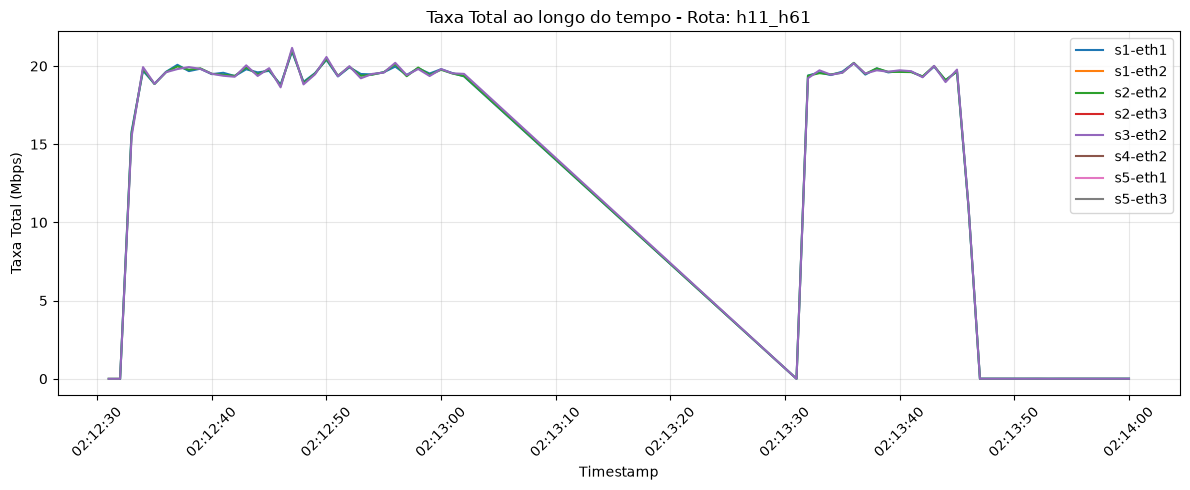

In [19]:
rota_para_validar = df_feature_store['rota_id'].unique()[0]
df_rota = df_feature_store[df_feature_store['rota_id'] == rota_para_validar]

colunas_taxa = [col for col in df_rota.columns if col.startswith('taxa_total_Mbps__')]

fig = plt.figure(figsize=(12, 5))
for coluna in colunas_taxa:
    interface = coluna.replace('taxa_total_Mbps__', '')
    plt.plot(df_rota['timestamp'], df_rota[coluna], label=interface, linewidth=1.5)

plt.legend()
plt.xlabel('Timestamp')
plt.ylabel('Taxa Total (Mbps)')
plt.title(f'Taxa Total ao longo do tempo - Rota: {rota_para_validar}')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


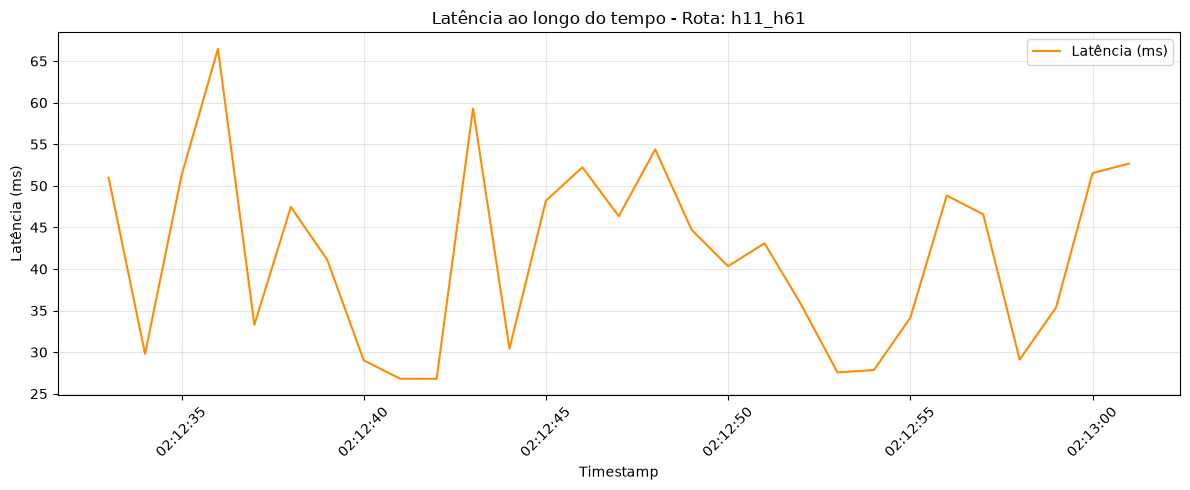

In [20]:
fig = plt.figure(figsize=(12, 5))
plt.plot(df_rota['timestamp'], df_rota['latencia_ms'], color='darkorange', linewidth=1.5, label='Latência (ms)')

plt.legend()
plt.xlabel('Timestamp')
plt.ylabel('Latência (ms)')
plt.title(f'Latência ao longo do tempo - Rota: {rota_para_validar}')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


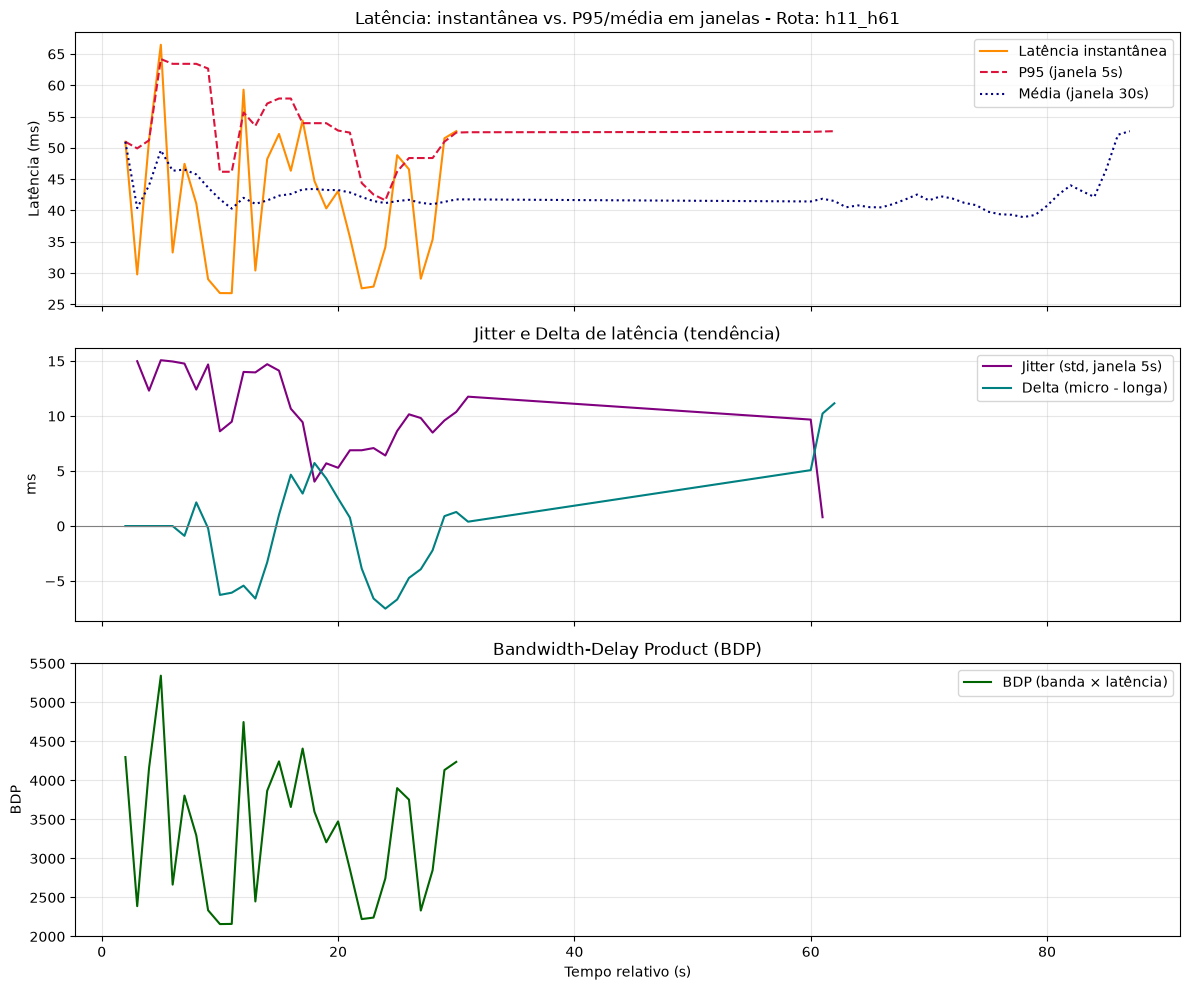

In [21]:
# Validação das features derivadas: latência bruta vs. p95/jitter (janela micro) e delta micro-longa
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(df_rota['tempo_relativo_s'], df_rota['latencia_ms'], label='Latência instantânea', color='darkorange')
axes[0].plot(df_rota['tempo_relativo_s'], df_rota['latencia_p95_micro_5s'], label='P95 (janela 5s)', color='crimson', linestyle='--')
axes[0].plot(df_rota['tempo_relativo_s'], df_rota['latencia_media_longa_30s'], label='Média (janela 30s)', color='navy', linestyle=':')
axes[0].set_ylabel('Latência (ms)')
axes[0].set_title(f'Latência: instantânea vs. P95/média em janelas - Rota: {rota_para_validar}')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(df_rota['tempo_relativo_s'], df_rota['latencia_jitter_micro_5s'], label='Jitter (std, janela 5s)', color='purple')
axes[1].plot(df_rota['tempo_relativo_s'], df_rota['latencia_delta_micro_longa'], label='Delta (micro - longa)', color='teal')
axes[1].axhline(0, color='gray', linewidth=0.8)
axes[1].set_ylabel('ms')
axes[1].set_title('Jitter e Delta de latência (tendência)')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(df_rota['tempo_relativo_s'], df_rota['bdp'], label='BDP (banda × latência)', color='darkgreen')
axes[2].set_ylabel('BDP')
axes[2].set_xlabel('Tempo relativo (s)')
axes[2].set_title('Bandwidth-Delay Product (BDP)')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 11. Exemplo de consulta à Feature Store

Função utilitária que lê os arquivos Parquet particionados e filtra por rota(s) e intervalo de tempo.

In [22]:
def get_features(rotas, inicio=None, fim=None, pasta_origem=FEATURE_STORE_FOLDER):
    """
    Consulta a feature store para uma ou mais rotas, filtrando por intervalo de tempo.

    rotas: lista de rota_id (ex: ['h11_h61'])
    inicio, fim: strings ou pd.Timestamp delimitando o intervalo (opcional)
    """
    dfs = []
    for rota_id in rotas:
        caminho = os.path.join(pasta_origem, f'{rota_id}.parquet')
        if not os.path.exists(caminho):
            print(f"Aviso: arquivo não encontrado para rota '{rota_id}': {caminho}")
            continue
        dfs.append(pd.read_parquet(caminho))

    if not dfs:
        return pd.DataFrame()

    df_resultado = pd.concat(dfs, ignore_index=True)

    if inicio is not None:
        df_resultado = df_resultado[df_resultado['timestamp'] >= pd.Timestamp(inicio)]
    if fim is not None:
        df_resultado = df_resultado[df_resultado['timestamp'] <= pd.Timestamp(fim)]

    return df_resultado.sort_values(['rota_id', 'timestamp']).reset_index(drop=True)

# Exemplo de uso: consultar a rota validada em um intervalo específico
exemplo_resultado = get_features(
    rotas=[rota_para_validar],
    inicio='2026-08-18 02:12:33',
    fim='2026-08-18 02:12:40'
)

print(f"Registros encontrados: {len(exemplo_resultado)}")
exemplo_resultado.head(10)


Registros encontrados: 8


,tempo_relativo_s,rota_id,timestamp,taxa_total_Mbps__s1-eth1,taxa_total_Mbps__s1-eth2,taxa_total_Mbps__s2-eth2,taxa_total_Mbps__s2-eth3,taxa_total_Mbps__s3-eth2,taxa_total_Mbps__s4-eth2,taxa_total_Mbps__s5-eth1,...,latencia_jitter_longa_30s,latencia_media_longa_30s,banda_disp_min_longa_30s,banda_disp_media_longa_30s,banda_utilizacao_longa_30s,latencia_delta_micro_longa,banda_delta_micro_longa,bdp,num_interfaces_ativas,latencia_por_salto
0,2,h11_h61,2026-08-18 02:12:33,15.808823,NaN,15.672409,NaN,15.478409,NaN,NaN,...,NaN,50.978306,84.346786,94.782049,0.052180,0.000000,0.889903,4299.856324,3,16.992769
1,3,h11_h61,2026-08-18 02:12:34,19.703384,NaN,19.805695,NaN,19.930740,NaN,NaN,...,14.985575,40.381905,80.186727,91.133218,0.088668,0.000000,0.879885,2388.401992,3,9.928501
2,4,h11_h61,2026-08-18 02:12:35,18.861938,NaN,18.850739,NaN,18.862675,NaN,NaN,...,12.309023,43.997995,80.186727,89.134884,0.108651,0.000000,0.899611,4156.895774,3,17.076725
3,5,h11_h61,2026-08-18 02:12:36,19.627010,NaN,19.604544,NaN,19.604544,NaN,NaN,...,15.075777,49.616514,80.186727,87.677065,0.123229,0.000000,0.914569,5343.554584,3,22.157357
4,6,h11_h61,2026-08-18 02:12:37,20.078522,NaN,19.976959,NaN,19.806442,NaN,NaN,...,14.959447,46.350759,80.046026,86.586916,0.134131,0.000000,0.924459,2664.551344,3,11.095914
5,7,h11_h61,2026-08-18 02:12:38,19.675138,NaN,19.764883,NaN,19.934553,NaN,NaN,...,13.387725,46.534757,80.046026,85.789611,0.142104,-0.888710,0.933050,3806.272978,3,15.818249
6,8,h11_h61,2026-08-18 02:12:39,19.829178,NaN,19.851166,NaN,19.817062,NaN,NaN,...,12.392332,45.759186,80.046026,85.164936,0.148351,2.150912,0.939894,3295.347169,3,13.701919
7,9,h11_h61,2026-08-18 02:12:40,19.480190,NaN,19.503555,NaN,19.503555,NaN,NaN,...,12.910452,43.666089,80.046026,84.698865,0.153011,-0.199143,0.945066,2335.782950,3,9.671471
